In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#read data
df = pd.read_csv('data/stud.csv')
print(df.shape)
df.head(5)

(1002, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
#perform EDA
'''
# check for null/missing values
print(df.isnull().sum())

# Check Duplicates
print(df.duplicated().sum())
# got 2 duplicate rows, remove duplicates
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

# Check data type
print(df.info())

# Check the number of unique values of each column
print(df.nunique())

# Check statistics of data set
print(df.describe())

'''

# Check various categories present in the different categorical column
for col in df.columns:
    if df[col].dtype == "str":
        print(f' Categorical column "{col}" unique values are -{df[col].unique()} \n')

 Categorical column "gender" unique values are -<StringArray>
['female', 'male']
Length: 2, dtype: str 

 Categorical column "race_ethnicity" unique values are -<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str 

 Categorical column "parental_level_of_education" unique values are -<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 

 Categorical column "lunch" unique values are -<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str 

 Categorical column "test_preparation_course" unique values are -<StringArray>
['none', 'completed']
Length: 2, dtype: str 



In [5]:
# define numerical & categorical columns
categorical_cols = []
numerical_cols = []
for col in df.columns:
    if df[col].dtype == "str":
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print(f'total {len(categorical_cols)} categorical_cols we have: {categorical_cols}\n')
print(f'total {len(numerical_cols)} numerical_cols we have : {numerical_cols}')

total 5 categorical_cols we have: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

total 3 numerical_cols we have : ['math_score', 'reading_score', 'writing_score']


In [6]:
#Add new columns total_score & average
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = round(df['total_score'] / len(numerical_cols),2)
print(df.head(2))

   gender race_ethnicity parental_level_of_education     lunch  \
0  female        group B           bachelor's degree  standard   
1  female        group C                some college  standard   

  test_preparation_course  math_score  reading_score  writing_score  \
0                    none          72             72             74   
1               completed          69             90             88   

   total_score  average  
0          218    72.67  
1          247    82.33  


In [7]:
# find total students who scored full marks
print(f'Number of students with full marks in Maths: {df[df['math_score']==100]['math_score'].count()}')
print(f'Number of students with full marks in Writing: {df[df['writing_score']==100]['writing_score'].count()}')
print(f'Number of students with full marks in Reading: {df[df['reading_score']==100]['reading_score'].count()}')

# find total students who scored less marks
print(f'Number of students with poor marks in Maths: {df[df['math_score']<=20]['math_score'].count()}')
print(f'Number of students with poor marks in Writing: {df[df['writing_score']<=20]['writing_score'].count()}')
print(f'Number of students with poor marks in Reading: {df[df['reading_score']<=20]['reading_score'].count()}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17
Number of students with poor marks in Maths: 4
Number of students with poor marks in Writing: 3
Number of students with poor marks in Reading: 1


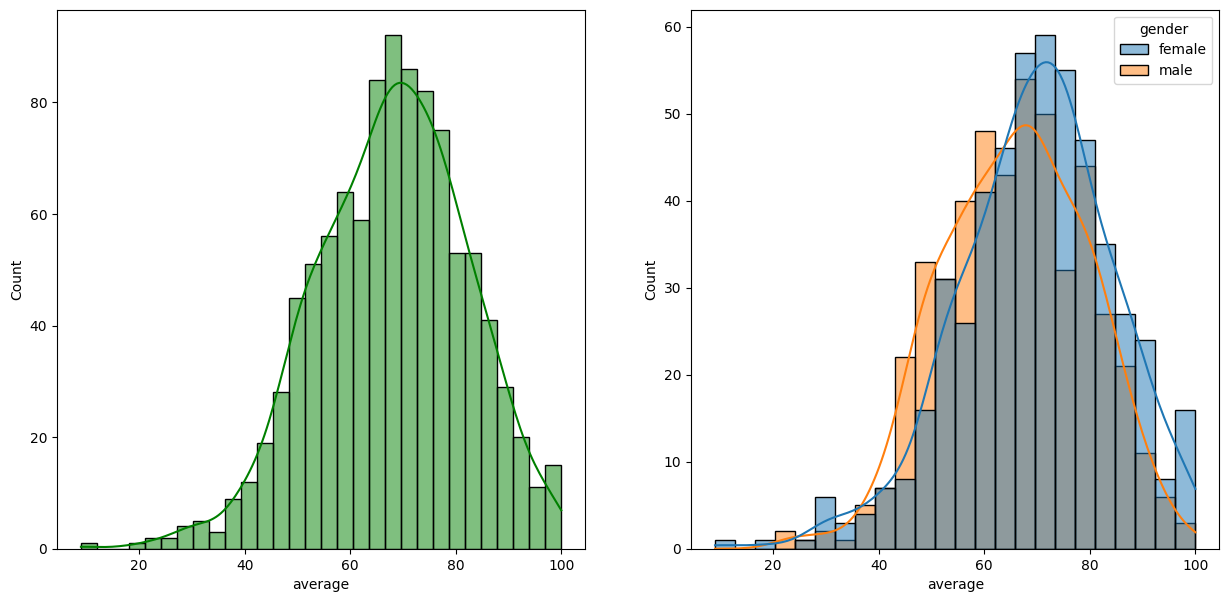

In [8]:
# Visualization
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

#Insight - Female students tend to perform well then male students.

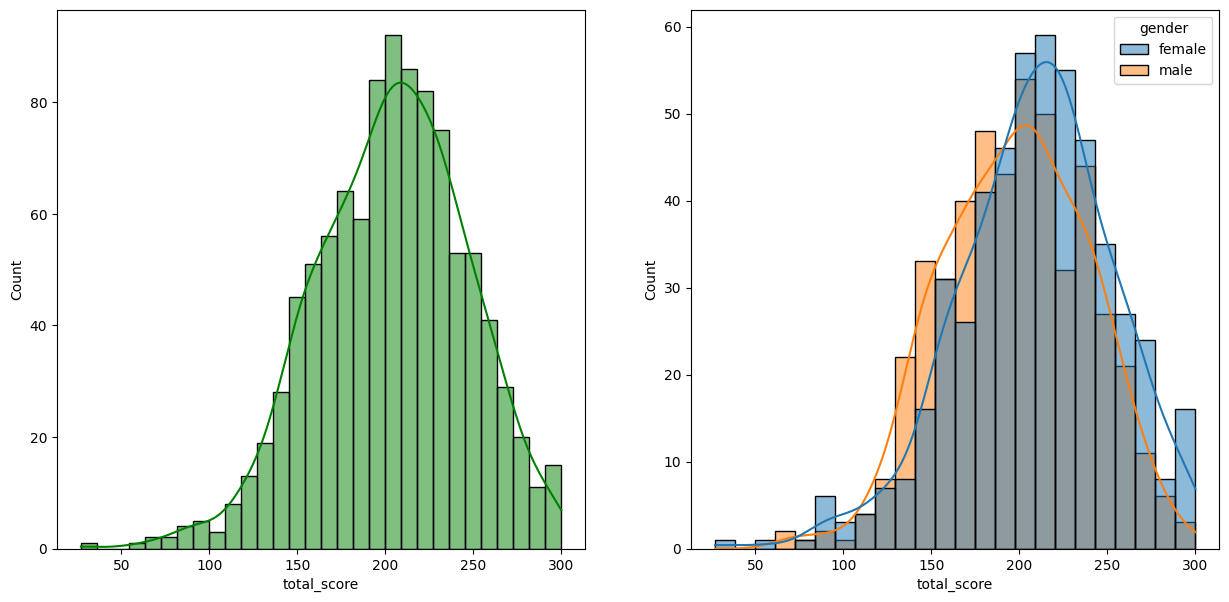

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

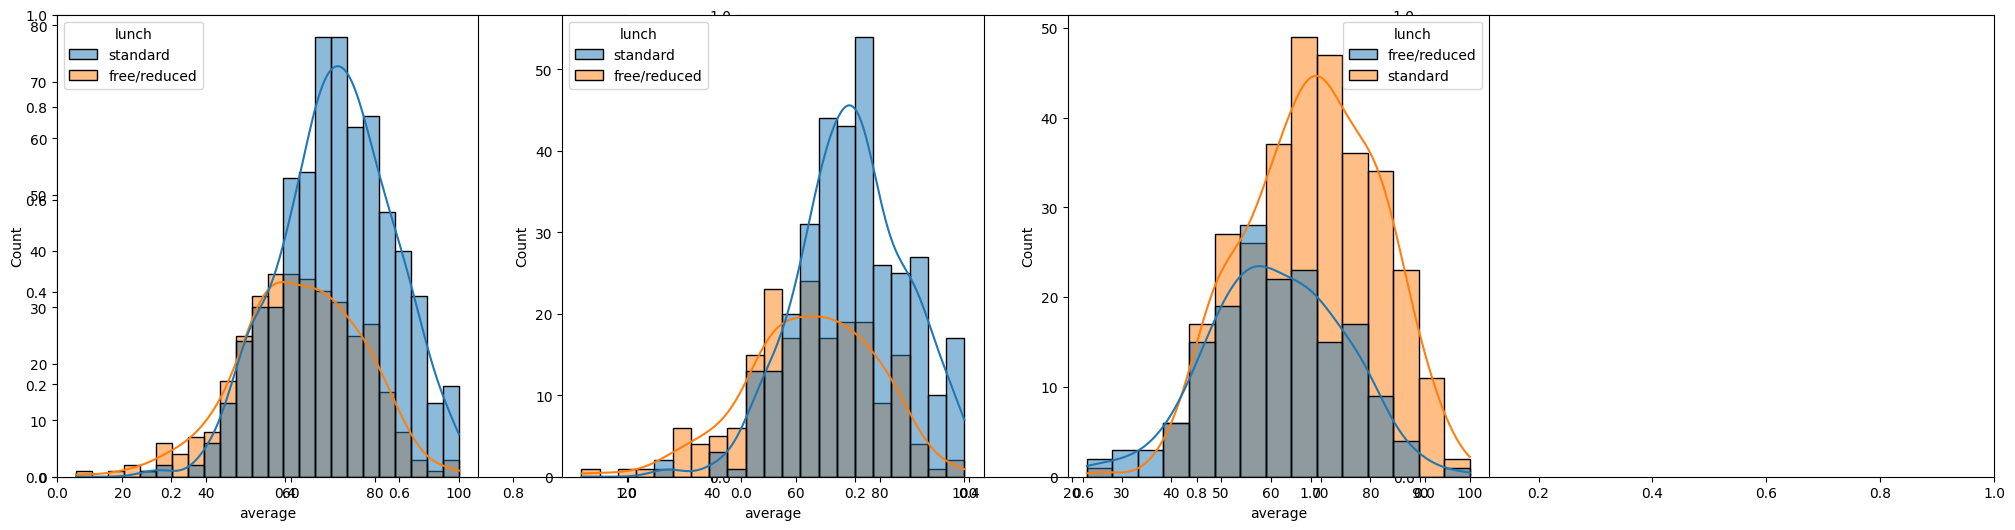

'\nInsights\nStandard lunch helps perform well in exams.\nStandard lunch helps perform well in exams be it a male or a female.\n'

In [10]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

'''
Insights
Standard lunch helps perform well in exams.
Standard lunch helps perform well in exams be it a male or a female.
'''

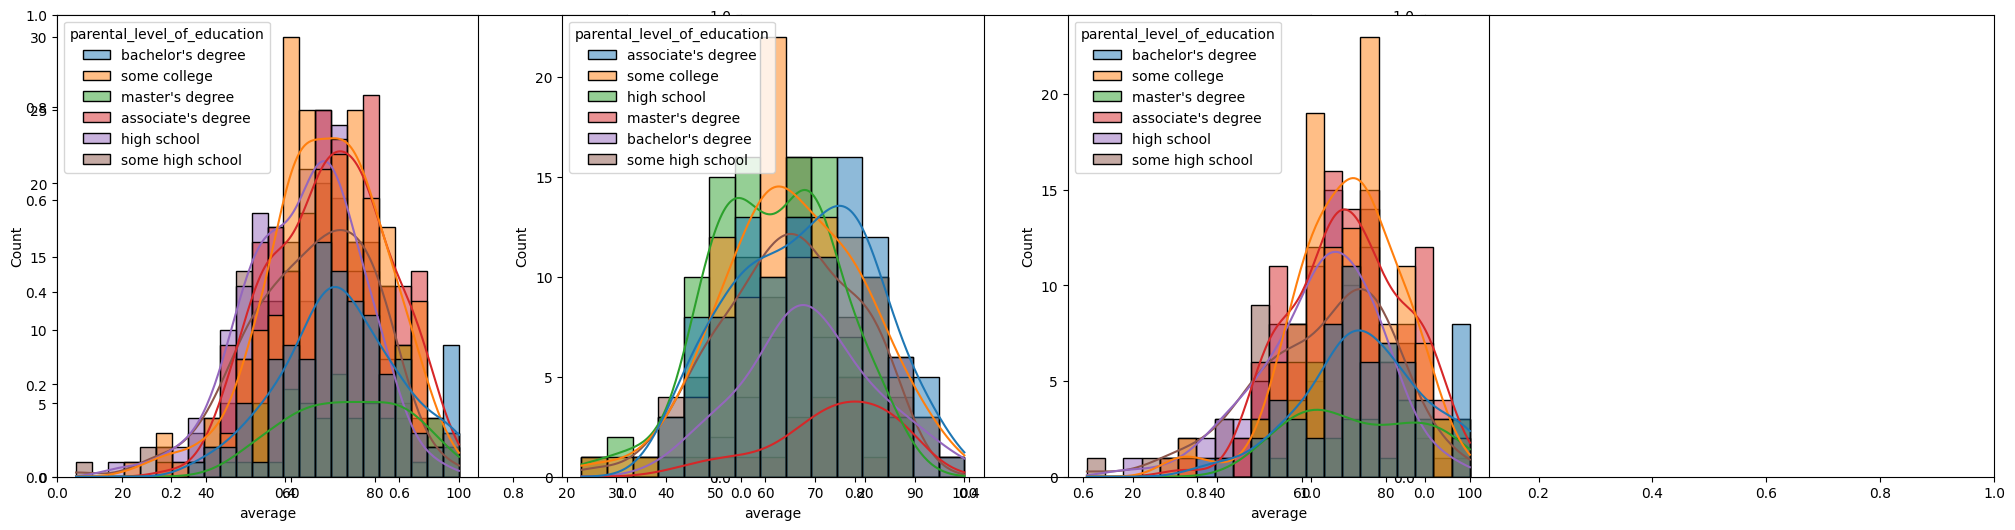

"\nInsights\nIn general parent's education don't help student perform well in exam.\n2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam\n3rd plot we can see there is no effect of parent's education on female students.\n"

In [11]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

'''
Insights
In general parent's education don't help student perform well in exam.
2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
3rd plot we can see there is no effect of parent's education on female students.
'''

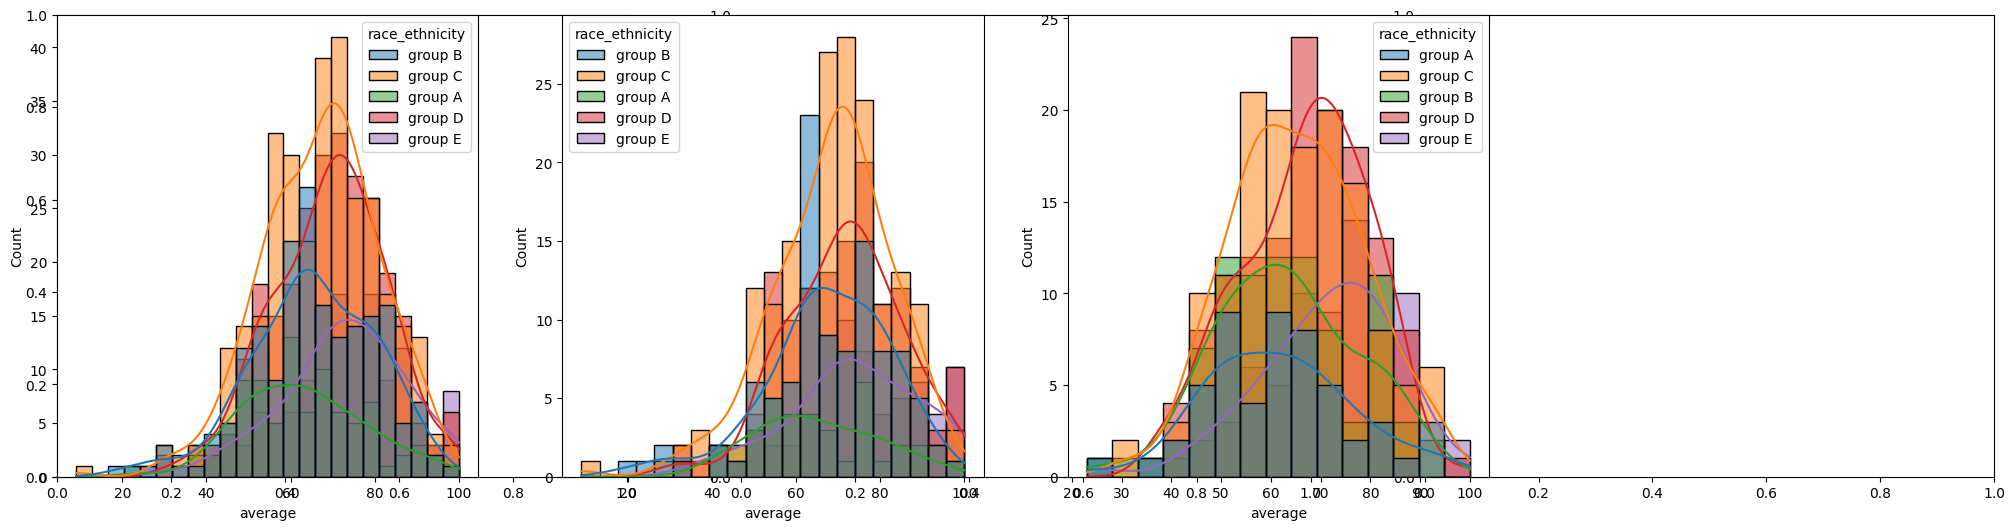

'\nInsights\nStudents of group A and group B tends to perform poorly in exam.\nStudents of group A and group B tends to perform poorly in exam irrespective of whether they are male or female\n'

In [12]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

'''
Insights
Students of group A and group B tends to perform poorly in exam.
Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female
'''

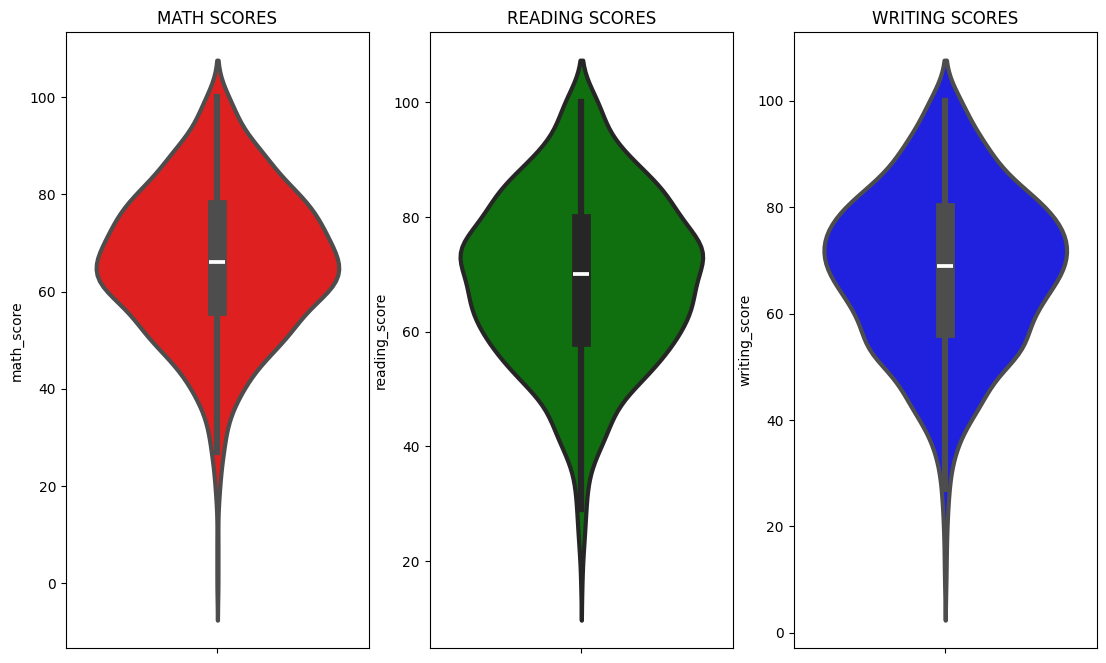

'\nInsights\nFrom the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80\n'

In [13]:
# Maximumum score of students in all three subjects

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

'''
Insights
From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80
'''

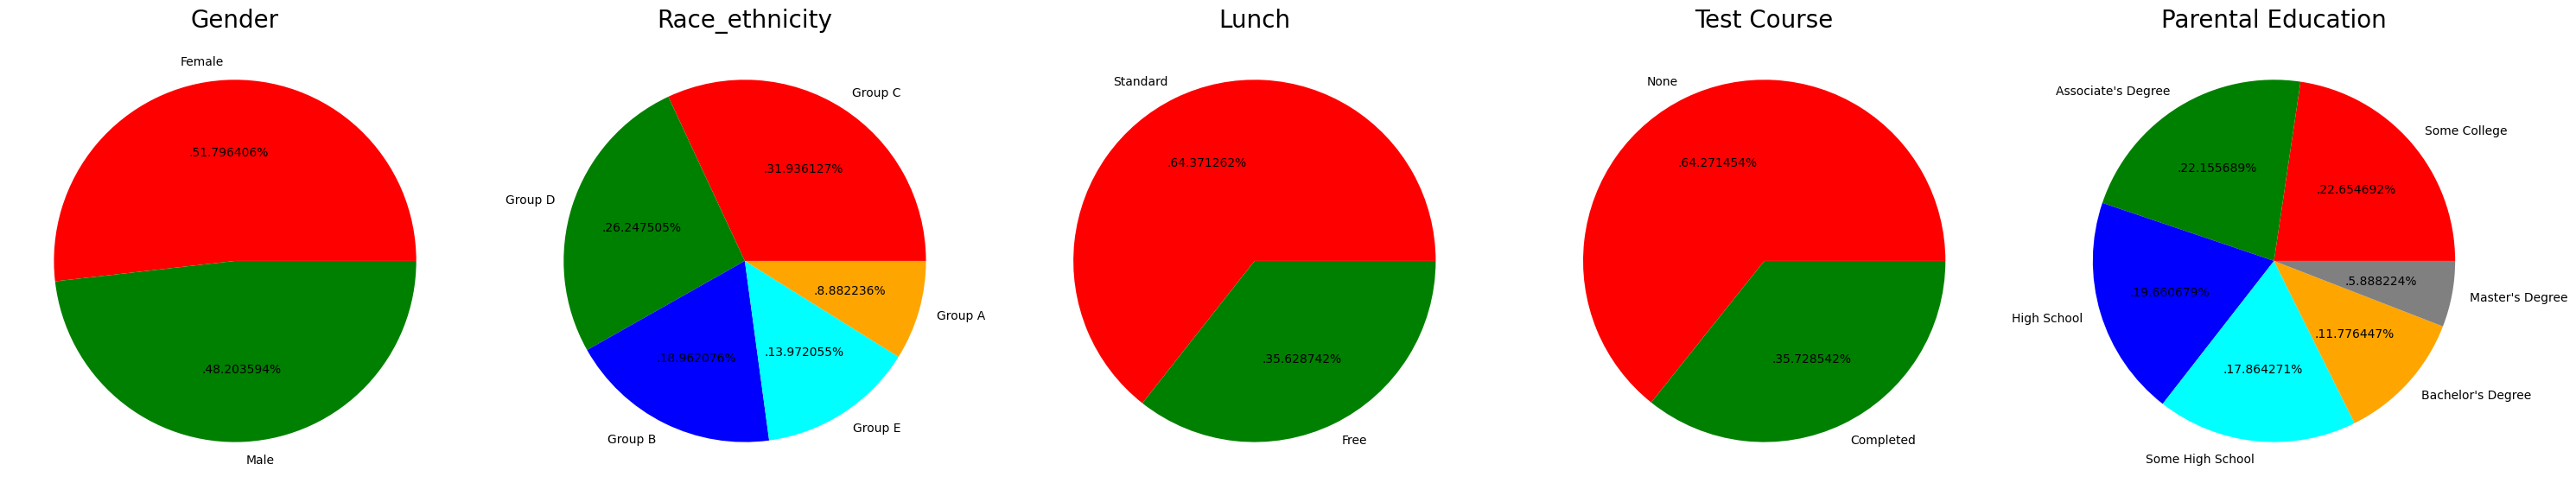

'\nInsights\nNumber of Male and Female students is almost equal\nNumber students are greatest in Group C\nNumber of students who have standard lunch are greater\nNumber of students who have not enrolled in any test preparation course is greater\nNumber of students whose parental education is "Some College" is greater followed closely by "Associate\'s Degree"\n'

In [14]:
# Multivariate analysis using pieplot
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

'''
Insights
Number of Male and Female students is almost equal
Number students are greatest in Group C
Number of students who have standard lunch are greater
Number of students who have not enrolled in any test preparation course is greater
Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"
'''

C:\Users\AnshuSrivastava\AppData\Local\Temp\ipykernel_10772\160382455.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)


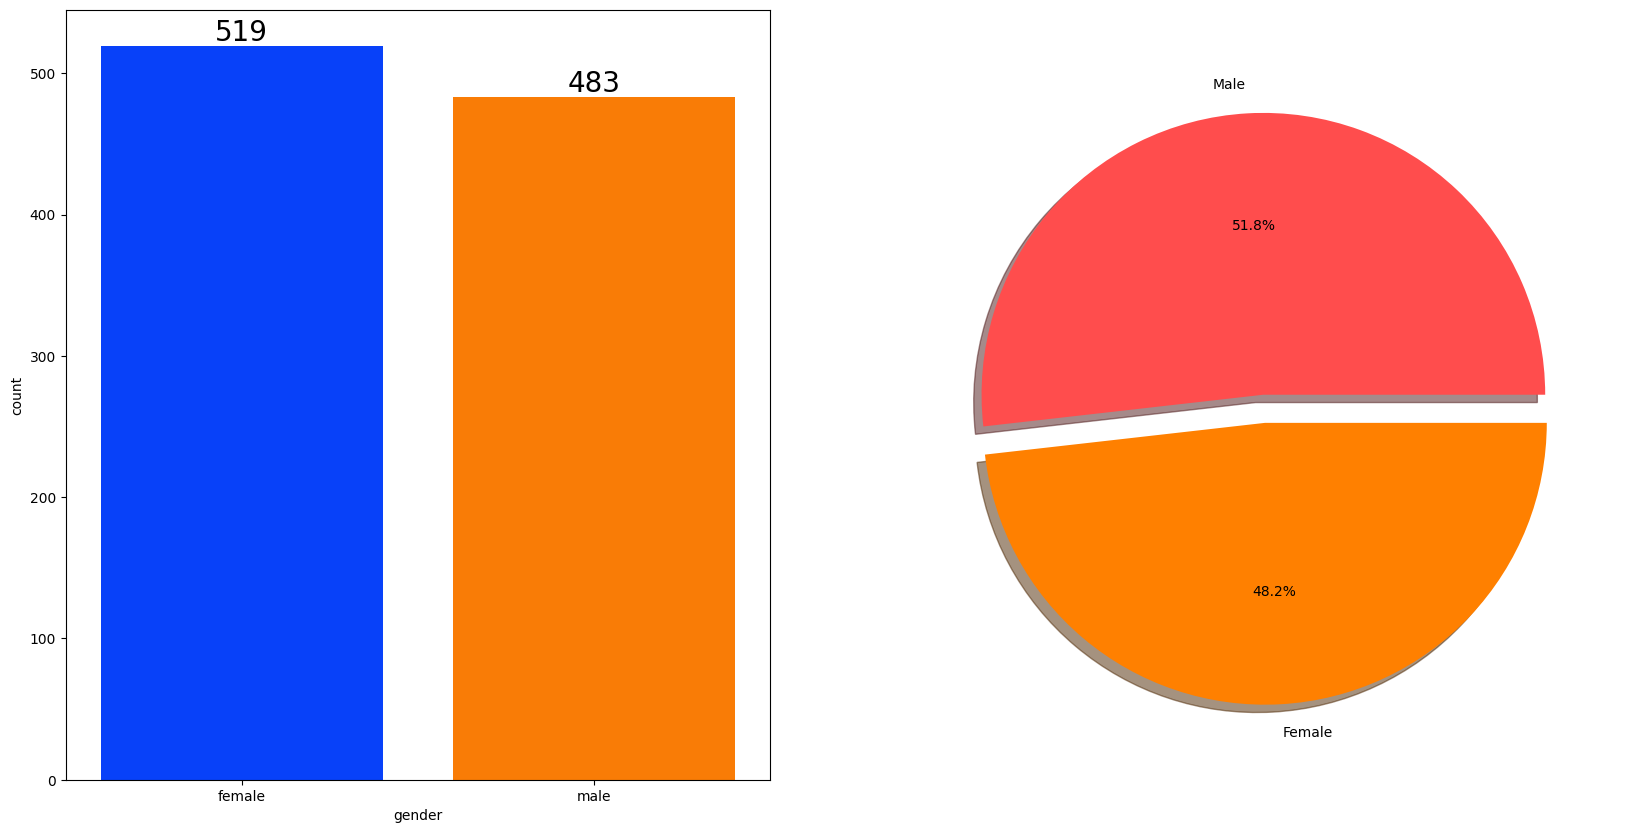

In [17]:
'''
Feature Wise Visualization
GENDER COLUMN - 
'''
# UNIVARIATE ANALYSIS - How is distribution of Gender ?
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

# Insight - Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)


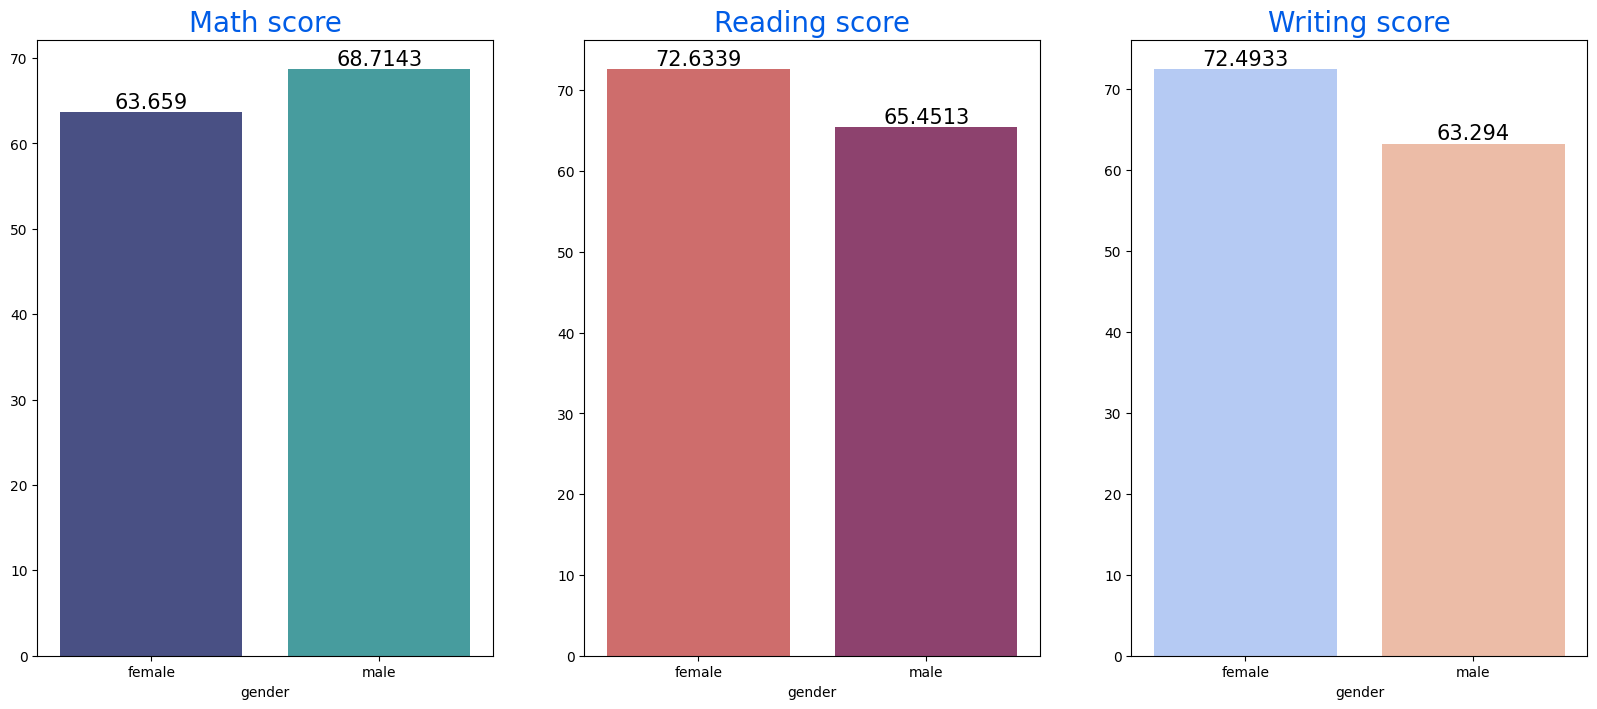

In [24]:
Group_data=df.groupby('gender')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data['math_score'].mean().index,y=Group_data['math_score'].mean().values,hue=Group_data['math_score'].mean().index,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data['reading_score'].mean().index,y=Group_data['reading_score'].mean().values,hue=Group_data['reading_score'].mean().index,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data['writing_score'].mean().index,y=Group_data['writing_score'].mean().values,hue=Group_data['writing_score'].mean().index,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

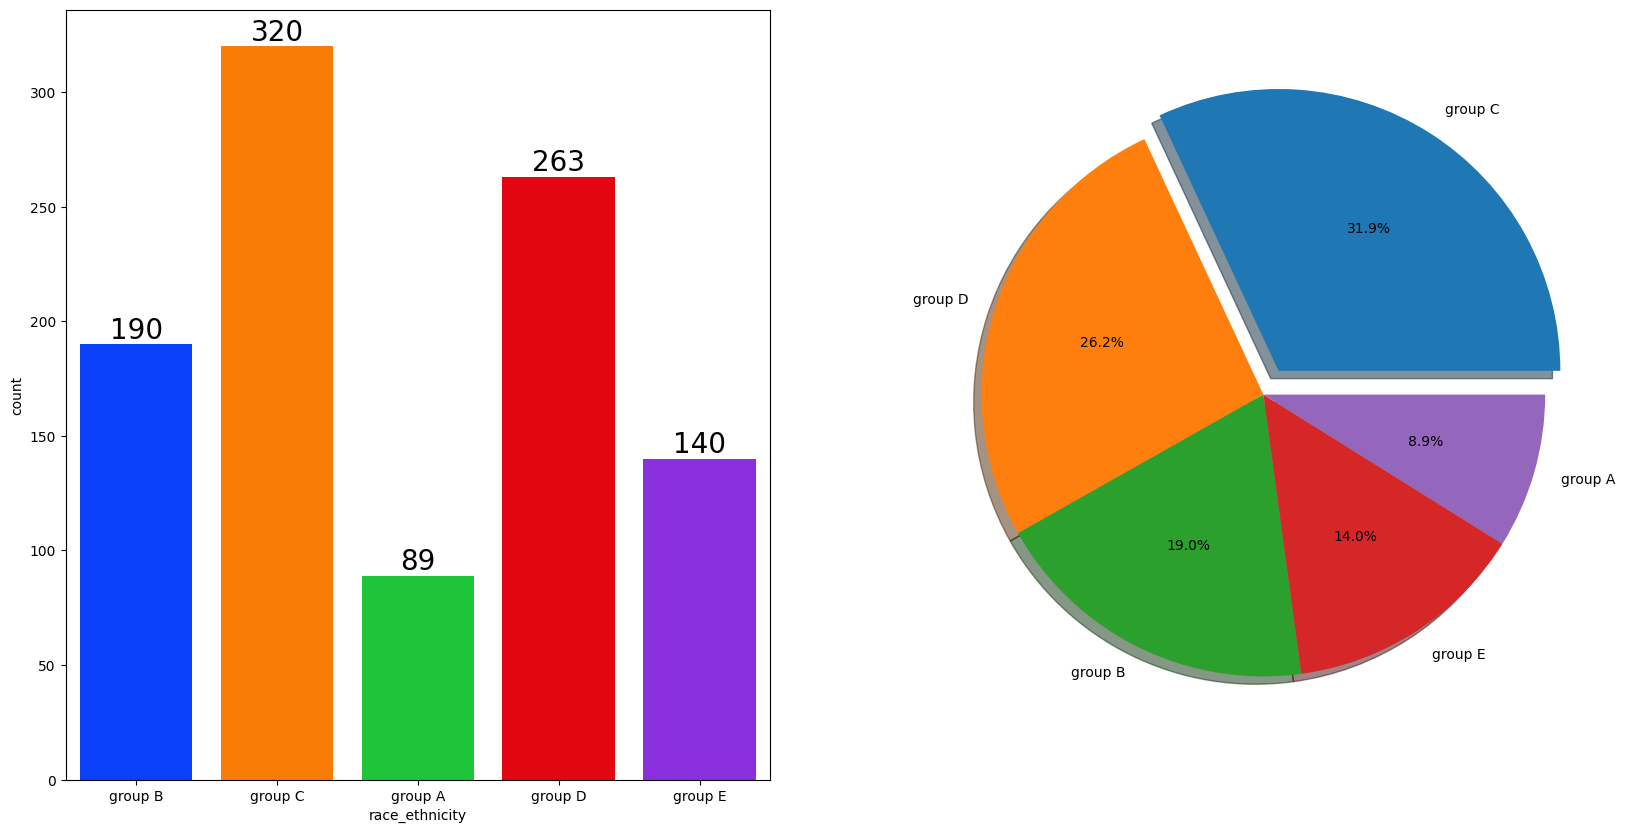

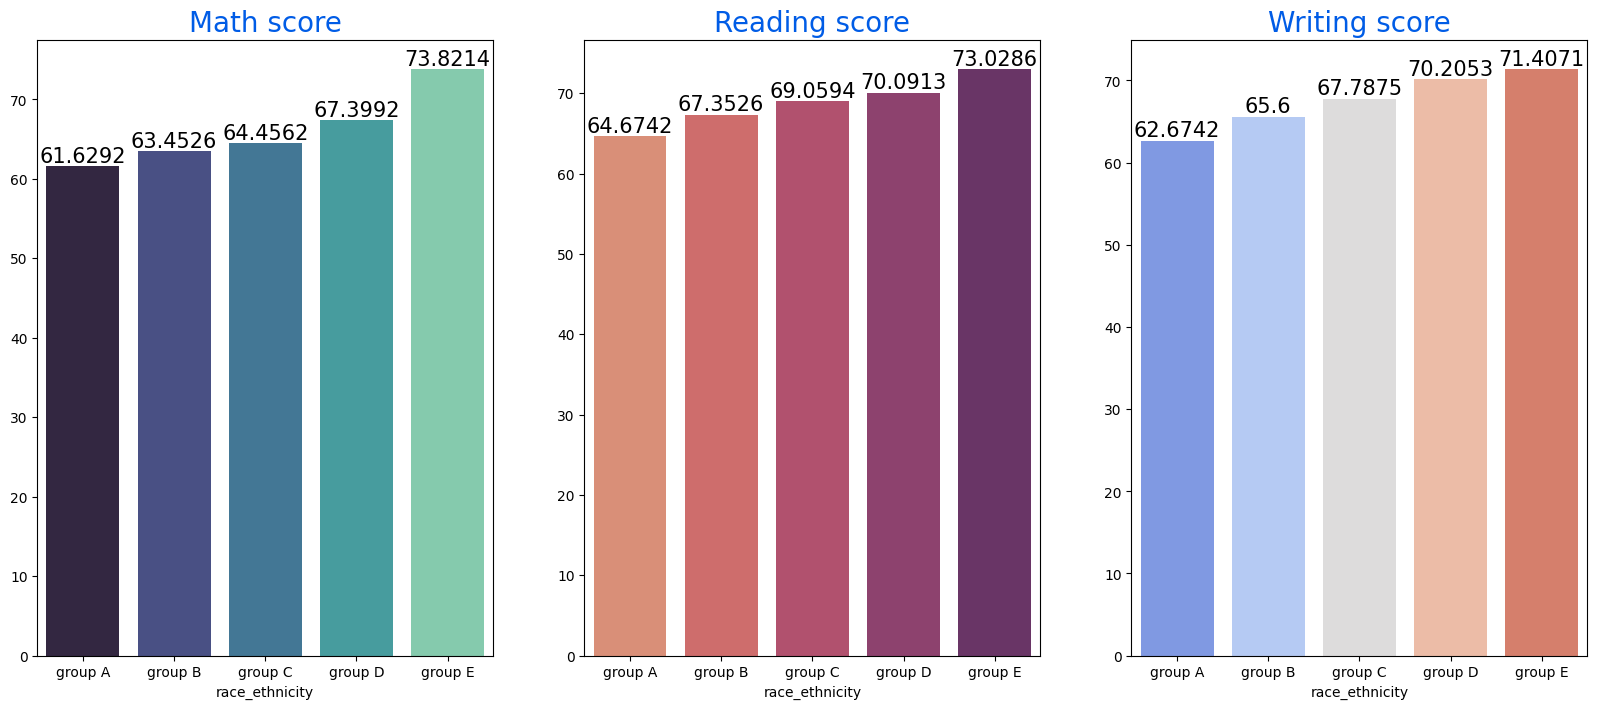

In [26]:
#Univariate analysis on race
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,hue = df['race_ethnicity'], palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#multivariate analysis
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,hue=Group_data2['math_score'].mean().index,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,hue=Group_data2['reading_score'].mean().index,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,hue=Group_data2['writing_score'].mean().index,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

C:\Users\AnshuSrivastava\AppData\Local\Temp\ipykernel_10772\3557784253.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['parental_level_of_education'], palette = 'Blues')


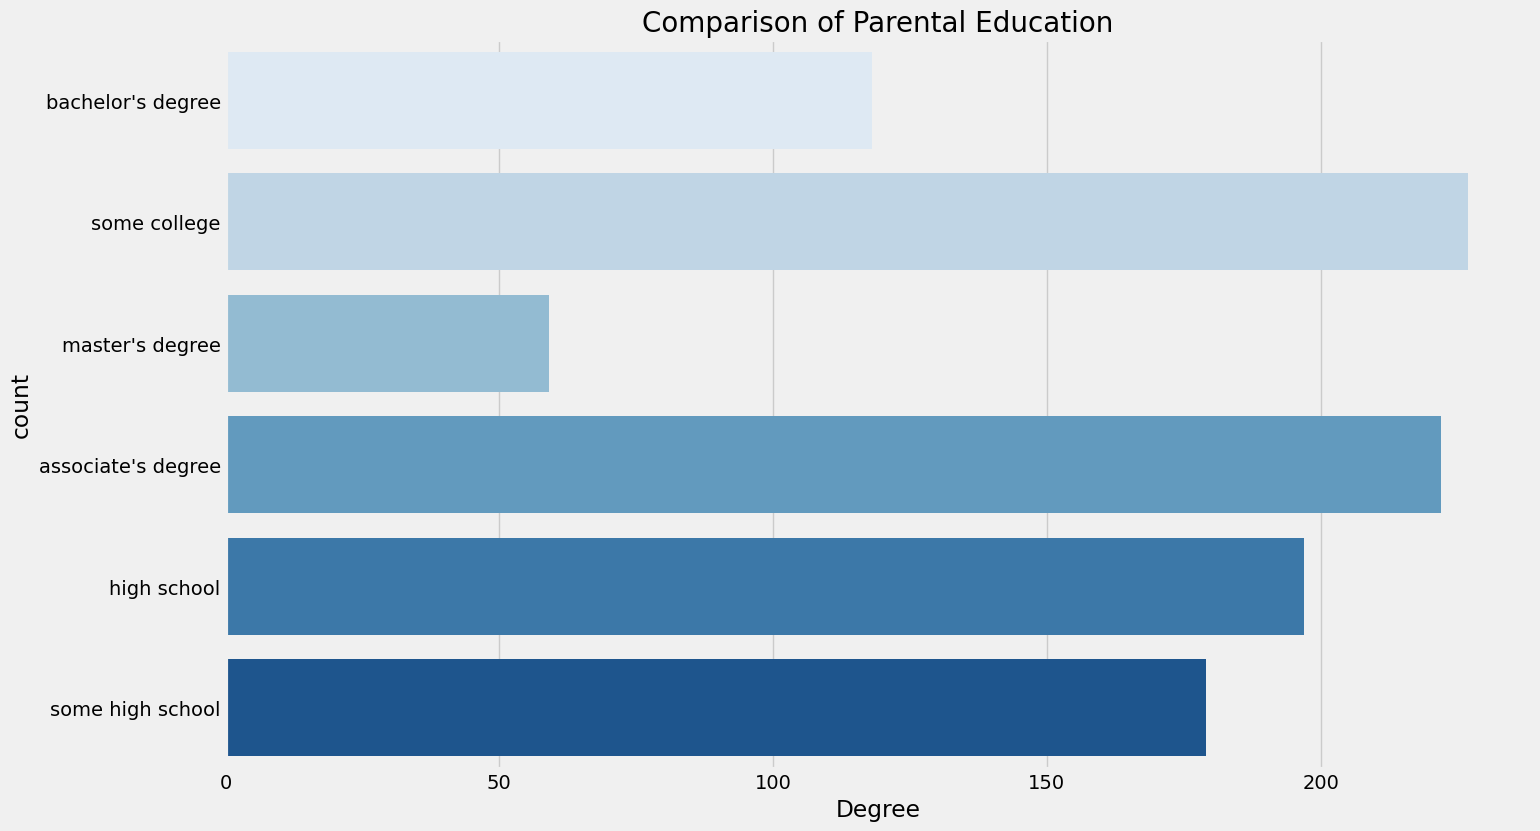

In [29]:
'''
PARENTAL LEVEL OF EDUCATION COLUMN
    What is educational background of student's parent ?
    Is parental education has any impact on student's performance ?
    UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )
'''
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

# Insights - Largest number of parents are from some college.


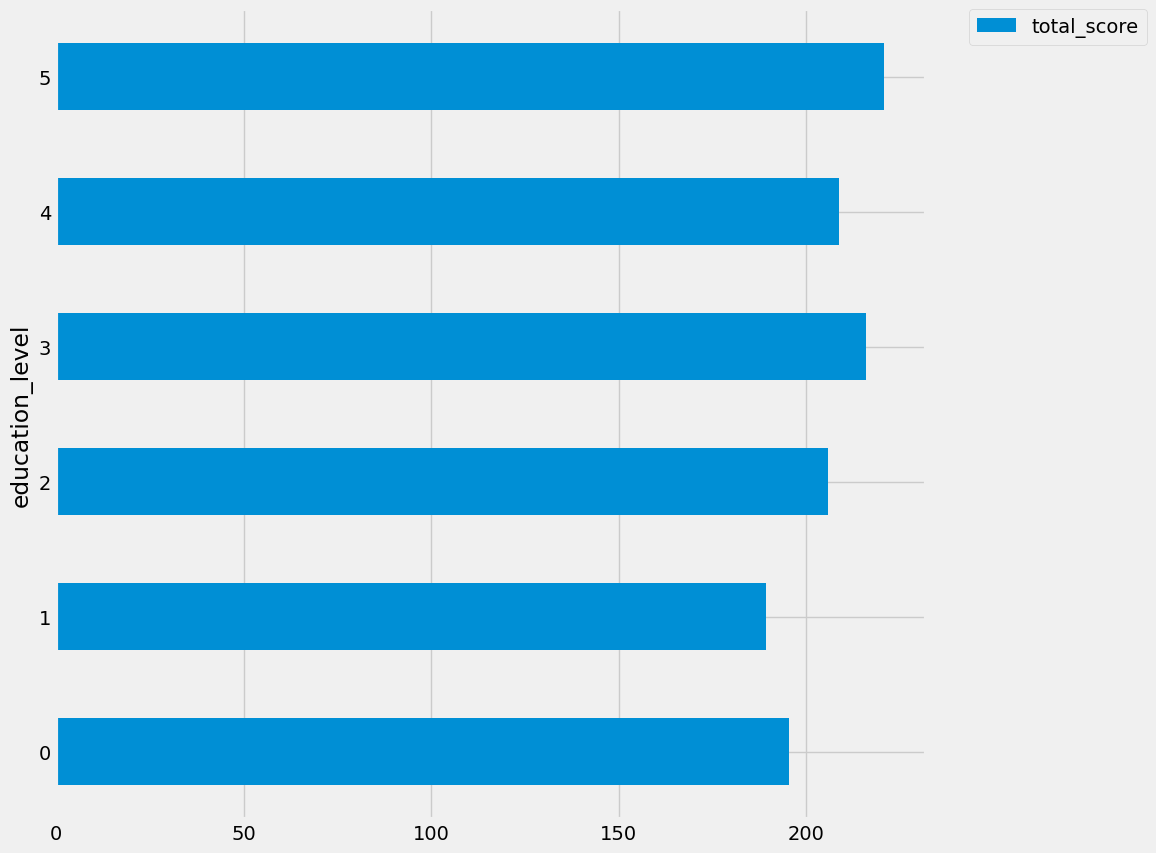

In [40]:
# BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )
education_level = {
    "bachelor's degree":3,
    "some college":2,
    "master's degree":5,
    "associate's degree":4,
    "high school":1,
    "some high school":0
}
df['education_level'] = df['parental_level_of_education'].map(education_level).astype('int')
#print(df.info(4))
df.groupby('education_level')['total_score'].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
# Insights - The score of student whose parents possess master and bachelor level education are higher than others

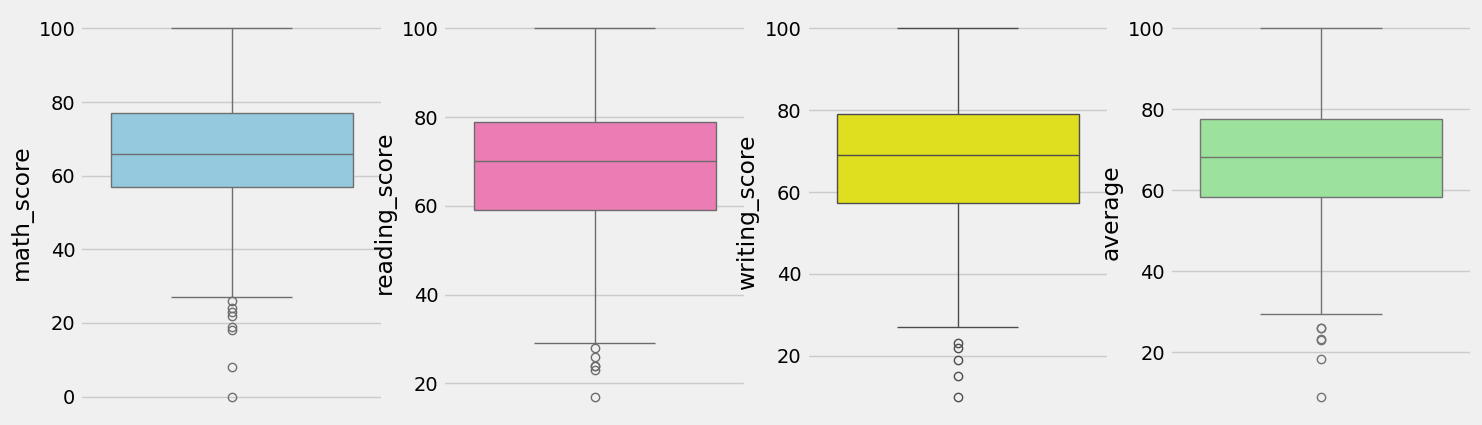

In [41]:
#CHECKING OUTLIERS
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()


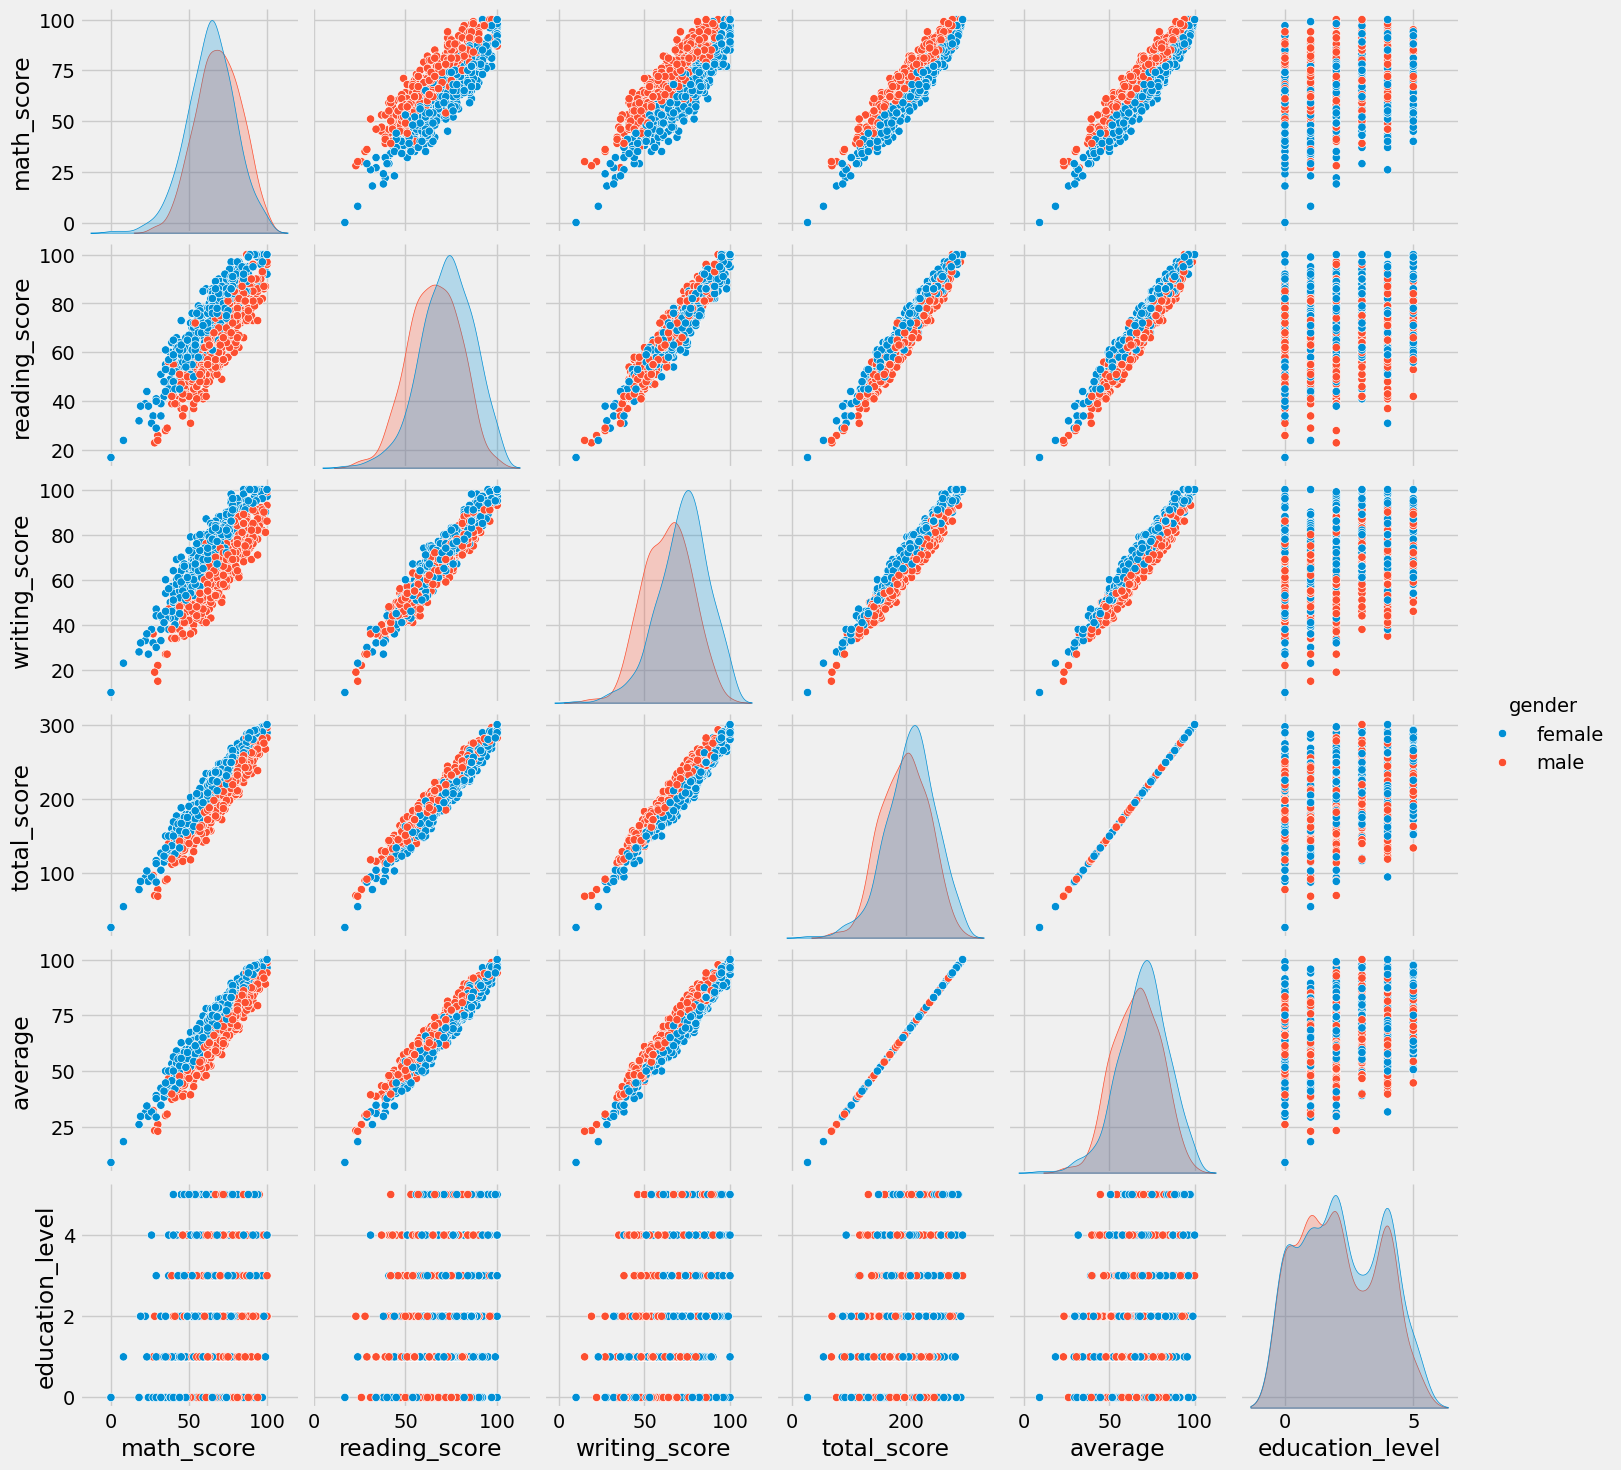

In [42]:
# 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT
sns.pairplot(df,hue = 'gender')
plt.show()
# Insights - From the above plot it is clear that all the scores increase linearly with each other.

In [ ]:
'''
Conclusions
Student's Performance is related with lunch, race, parental level education
Females lead in pass percentage and also are top-scorers
Student's Performance is not much related with test preparation course
Finishing preparation course is benefitial.
'''